
---
date: "2026-09-12"
date-modified: last-modified
format:
  html:
    toc: true
---


# Direction Fields of ODEs

A first-order [ordinary differential equation](ode-intro.ipynb) in standard form $y' = f(x, y)$ admits a direct geometric interpretation: rather than defining an explicit trajectory $y(x)$ algebraically, it prescribes a geometric rule specifying the tangent slope of any integral curve passing through a given point $(x, y)$.

## 1\. Geometric Definition of Direction Fields

::: {#def-direction-field}
## Direction Field (Slope Field)
Let $D \subseteq \mathbb{R}^2$ be an open domain and let $f: D \to \mathbb{R}$ be continuous. The **direction field** (or **slope field**) of the ODE $y' = f(x, y)$ is the geometric assignment that maps each point $(x, y) \in D$ to a short line segment centered at $(x, y)$ with slope:
$$
m(x, y) = f(x, y)
$$
:::

### 1.1\. The Vector Field Formulation

The graph of a differentiable curve $y = \phi(x)$ parameterized by $x \mapsto \begin{pmatrix} x \\ \phi(x) \end{pmatrix}$ has tangent velocity vector $\begin{pmatrix} 1 \\ \phi'(x) \end{pmatrix}$. Consequently, the ODE $y' = f(x, y)$ defines a planar **tangent vector field**:
$$
\mathbf{v}(x, y) = \begin{pmatrix} 1 \\ f(x, y) \end{pmatrix}
$$
Normalizing by Euclidean magnitude yields the **unit direction field**:
$$
\mathbf{u}(x, y) = \frac{1}{\sqrt{1 + [f(x, y)]^2}} \begin{pmatrix} 1 \\ f(x, y) \end{pmatrix}
$$
A differentiable curve $y = \phi(x)$ is a solution to the ODE if and only if its tangent vector is everywhere collinear with $\mathbf{v}(x, \phi(x))$. That is, solution curves are precisely the [integral curves]() of the vector field $\mathbf{v}$.


## 2\. Isoclines and Qualitative Flow

::: {#def-isocline}
## Isoclines
An **isocline** of the ODE $y' = f(x, y)$ corresponding to a constant slope $c \in \mathbb{R}$ is the level curve:
$$
\mathcal{I}_c = \left\{ (x, y) \in D : f(x, y) = c \right\}
$$
Along an isocline $\mathcal{I}_c$, all line segments of the direction field are mutually parallel with identical slope $c$. In particular:

* The **nullcline** $\mathcal{I}_0 = \{(x, y) : f(x, y) = 0\}$ identifies the locus of potential local extrema and horizontal inflection points.
* The level sets where $f(x, y) \to \pm \infty$ locate vertical tangents, indicating points where the standard form breaks down.
:::

::: {.callout-note}
## Intuition: Navigating a Flow Field
Think of the domain $D$ as the surface of a fluid flow and the unit vector field $\mathbf{u}(x, y)$ as the direction of local currents. Dropping a weightless tracer particle at $(x_0, y_0)$ results in a path governed entirely by the surrounding currents. The trajectory $y = \phi(x)$ is an integral curve that threads smoothly along the tangent arrows without ever cutting across them. Discrete steps along these tangent vectors form the foundation of [Euler's Method](euler-method.ipynb).
:::

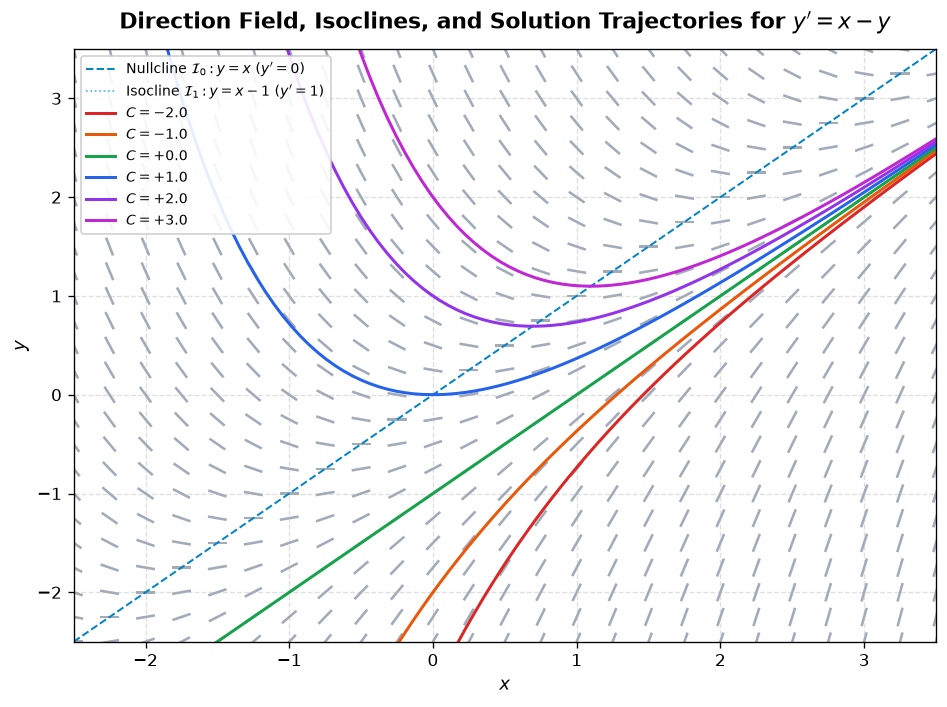

In [1]:

import numpy as np
import matplotlib.pyplot as plt

# Define ODE: y' = x - y
def f(x, y):
    return x - y

# Exact general solution: y(x) = x - 1 + C * exp(-x)
def exact_sol(x, C):
    return x - 1 + C * np.exp(-x)

# Setup coordinate grid
x_vals = np.linspace(-2.5, 3.5, 25)
y_vals = np.linspace(-2.5, 3.5, 25)
X, Y = np.meshgrid(x_vals, y_vals)

# Compute slopes and normalized direction vectors
S = f(X, Y)
N = np.sqrt(1 + S**2)
U = 1.0 / N
V = S / N

fig, ax = plt.subplots(figsize=(8, 6), dpi=120)

# Plot direction field
ax.quiver(X, Y, U, V, angles="xy", color="#64748b", alpha=0.6, width=0.003, headwidth=0, headlength=0, headaxislength=0, pivot="mid")

# Plot isoclines for c = -1, 0, 1 (dashed lines)
x_line = np.linspace(-2.5, 3.5, 100)
ax.plot(x_line, x_line - 0, "--", color="#0284c7", linewidth=1.2, label=r"Nullcline $\mathcal{I}_0: y = x$ ($y'=0$)")
ax.plot(x_line, x_line - 1, ":", color="#0ea5e9", linewidth=1.0, alpha=0.8, label=r"Isocline $\mathcal{I}_1: y = x - 1$ ($y'=1$)")

# Plot solution curves for various initial conditions C
C_values = [-2.0, -1.0, 0.0, 1.0, 2.0, 3.0]
colors = ["#dc2626", "#ea580c", "#16a34a", "#2563eb", "#9333ea", "#c026d3"]
for C, col in zip(C_values, colors):
    ax.plot(x_line, exact_sol(x_line, C), color=col, linewidth=1.8, label=f"$C = {C:+.1f}$")

ax.set_xlim(-2.5, 3.5)
ax.set_ylim(-2.5, 3.5)
ax.set_xlabel("$x$", fontsize=11)
ax.set_ylabel("$y$", fontsize=11)
ax.set_title(r"Direction Field, Isoclines, and Solution Trajectories for $y' = x - y$", fontsize=13, fontweight="bold", pad=12)
ax.grid(True, linestyle="--", alpha=0.4)
ax.legend(loc="upper left", fontsize=8.5, framealpha=0.9)
plt.tight_layout()
plt.show()